# Fraud Detection in Insurance Claims
### Using Logistic Regression, Decision Tree and Random Forest

Insurance fraud is a massive problem companies lose billions every year to fake or exaggerated claims. In this notebook, we dig into a real-world insurance claims dataset and build models that can automatically flag suspicious claims before they are paid out.

The dataset is the **Fraud Oracle** dataset, which contains details about policies, vehicles, accidents, and claimants. Our goal is to predict FraudFound_P where 1 means fraud and 0 means legitimate.

In [3]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])
print('imbalanced-learn is ready.')

imbalanced-learn is ready.


---
## Step 1 -- Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Task 1 -- Load the Dataset and Preview First 10 Records

Let's pull the data directly from GitHub and take a first look.

In [5]:
url = 'https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/fraud_oracle.csv'
df = pd.read_csv(url)

print(f'Dataset loaded! Shape: {df.shape}')
df.head(10)

Dataset loaded! Shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision
5,Oct,4,Friday,Honda,Urban,Wednesday,Nov,1,Male,Single,...,5 years,21 to 25,No,No,External,3 to 5,no change,1 vehicle,1994,Collision
6,Feb,1,Saturday,Honda,Urban,Monday,Feb,3,Male,Married,...,7 years,36 to 40,No,No,External,1 to 2,no change,1 vehicle,1994,Collision
7,Nov,1,Friday,Honda,Urban,Tuesday,Mar,4,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision
8,Dec,4,Saturday,Honda,Urban,Wednesday,Dec,5,Male,Single,...,6 years,31 to 35,No,Yes,External,3 to 5,no change,1 vehicle,1994,Collision
9,Apr,3,Tuesday,Ford,Urban,Wednesday,Apr,3,Male,Married,...,more than 7,36 to 40,No,No,External,3 to 5,no change,1 vehicle,1994,All Perils


---
## Task 2 -- Shape, Columns and Data Types

In [6]:
print(f'Total Rows    : {df.shape[0]}')
print(f'Total Columns : {df.shape[1]}')
print('\n--- Data Types ---')
print(df.dtypes)

Total Rows    : 15420
Total Columns : 33

--- Data Types ---
Month                   object
WeekOfMonth              int64
DayOfWeek               object
Make                    object
AccidentArea            object
DayOfWeekClaimed        object
MonthClaimed            object
WeekOfMonthClaimed       int64
Sex                     object
MaritalStatus           object
Age                      int64
Fault                   object
PolicyType              object
VehicleCategory         object
VehiclePrice            object
FraudFound_P             int64
PolicyNumber             int64
RepNumber                int64
Deductible               int64
DriverRating             int64
Days_Policy_Accident    object
Days_Policy_Claim       object
PastNumberOfClaims      object
AgeOfVehicle            object
AgeOfPolicyHolder       object
PoliceReportFiled       object
WitnessPresent          object
AgentType               object
NumberOfSuppliments     object
AddressChange_Claim     object
NumberOfC

---
## Task 3 -- Missing Value Check

Before we do anything, we need to check if any data is missing.

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print(missing_report[missing_report['Missing Count'] > 0])

if missing.sum() == 0:
    print('\nGreat news -- no missing values found in this dataset!')

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Great news -- no missing values found in this dataset!


---
## Task 4 -- Data Cleaning

Even without missing values, let's clean things up -- drop duplicates, fix the Age column where 0 does not make sense for a claimant, and remove columns that won't help prediction.

In [8]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Duplicates removed: {before - after}')

if 'Age' in df.columns:
    zero_age_count = (df['Age'] == 0).sum()
    median_age = df[df['Age'] > 0]['Age'].median()
    df['Age'] = df['Age'].replace(0, median_age)
    print(f'Age=0 entries replaced with median age ({median_age}): {zero_age_count} rows')

if 'PolicyNumber' in df.columns:
    df.drop('PolicyNumber', axis=1, inplace=True)
    print('Dropped PolicyNumber (ID column, not useful for modeling)')

print(f'\nClean dataset shape: {df.shape}')

Duplicates removed: 0
Age=0 entries replaced with median age (39.0): 320 rows
Dropped PolicyNumber (ID column, not useful for modeling)

Clean dataset shape: (15420, 32)


---
## Task 5 -- Separate Numerical and Categorical Features

In [9]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if 'FraudFound_P' in numerical_cols:
    numerical_cols.remove('FraudFound_P')

print(f'Numerical Features ({len(numerical_cols)}):')
print(numerical_cols)
print(f'\nCategorical Features ({len(categorical_cols)}):')
print(categorical_cols)

Numerical Features (7):
['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'RepNumber', 'Deductible', 'DriverRating', 'Year']

Categorical Features (24):
['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']


---
## Task 6 -- Exploratory Data Analysis (EDA)

Let's dig into the data visually. First -- how balanced is our target variable?

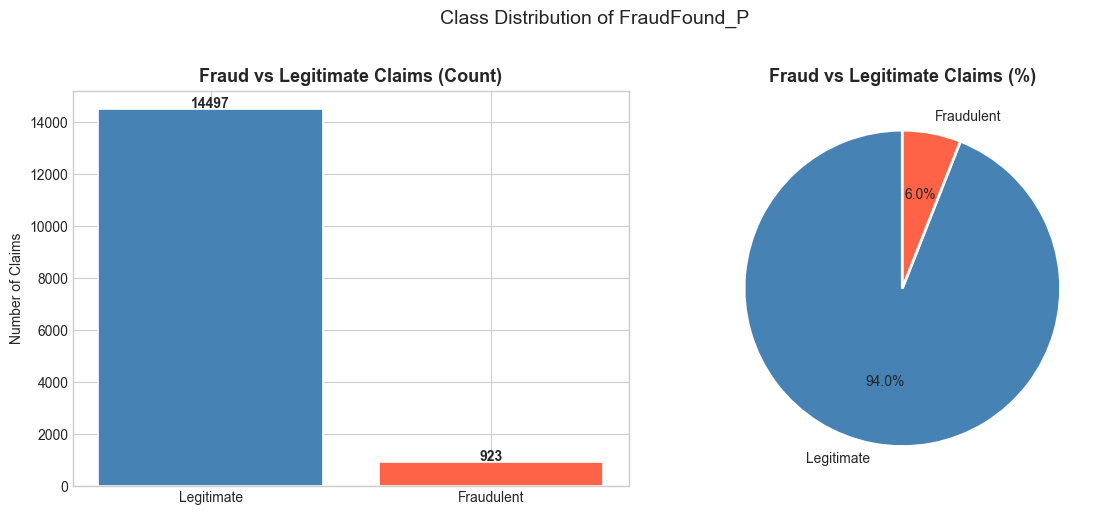

Legitimate claims : 14497 (94.0%)
Fraudulent claims : 923 (6.0%)

The dataset is clearly imbalanced -- we will handle this with SMOTE later.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fraud_counts = df['FraudFound_P'].value_counts()
labels = ['Legitimate', 'Fraudulent']

axes[0].bar(labels, fraud_counts.values, color=['steelblue', 'tomato'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Fraud vs Legitimate Claims (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Claims')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(fraud_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Fraud vs Legitimate Claims (%)', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution of FraudFound_P', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Legitimate claims : {fraud_counts[0]} ({fraud_counts[0]/len(df)*100:.1f}%)')
print(f'Fraudulent claims : {fraud_counts[1]} ({fraud_counts[1]/len(df)*100:.1f}%)')
print('\nThe dataset is clearly imbalanced -- we will handle this with SMOTE later.')

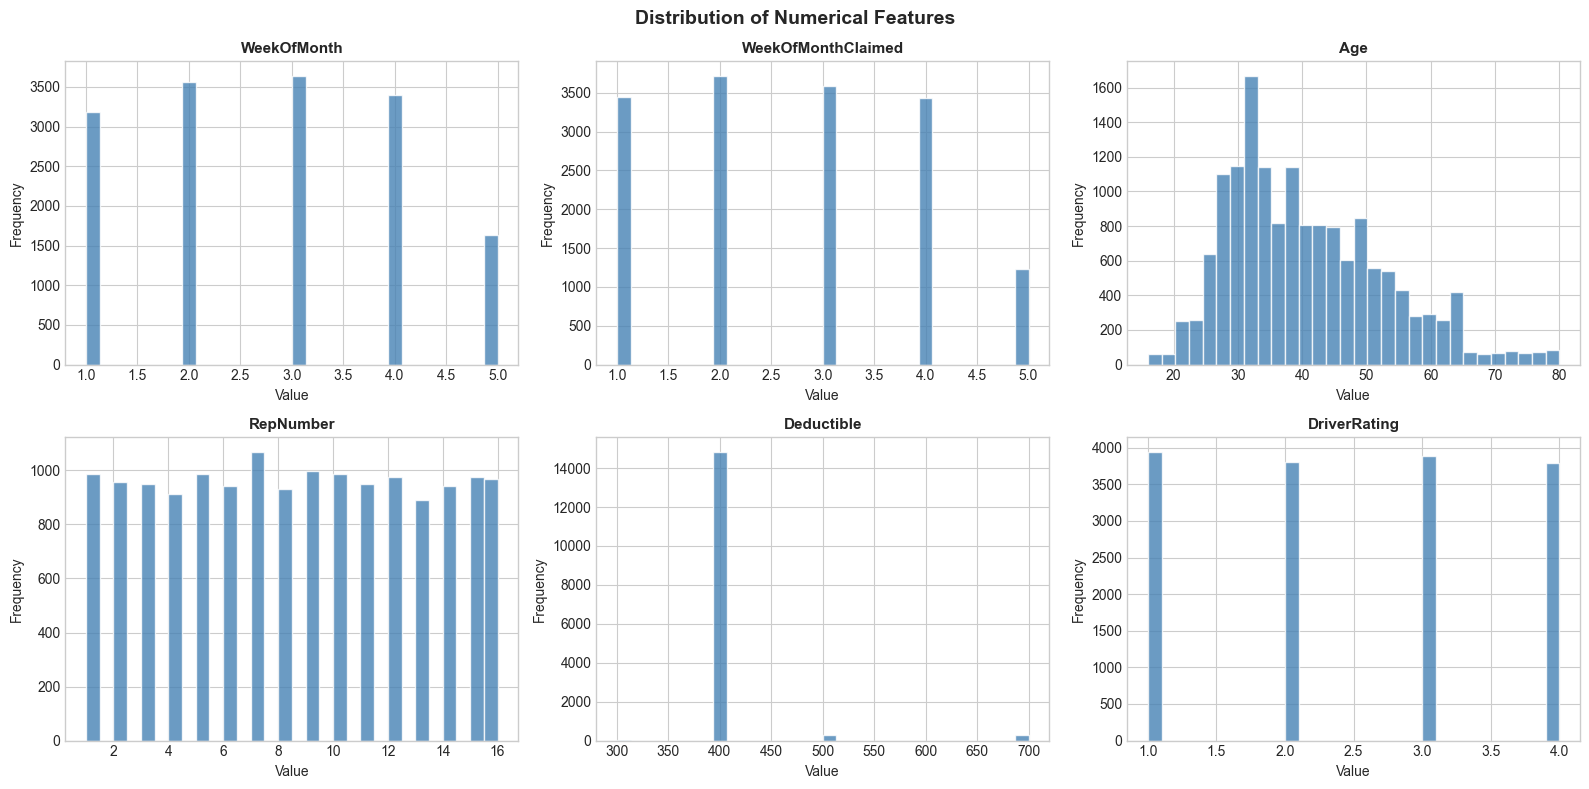

In [11]:
num_to_plot = [c for c in numerical_cols if c != 'FraudFound_P'][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_to_plot):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

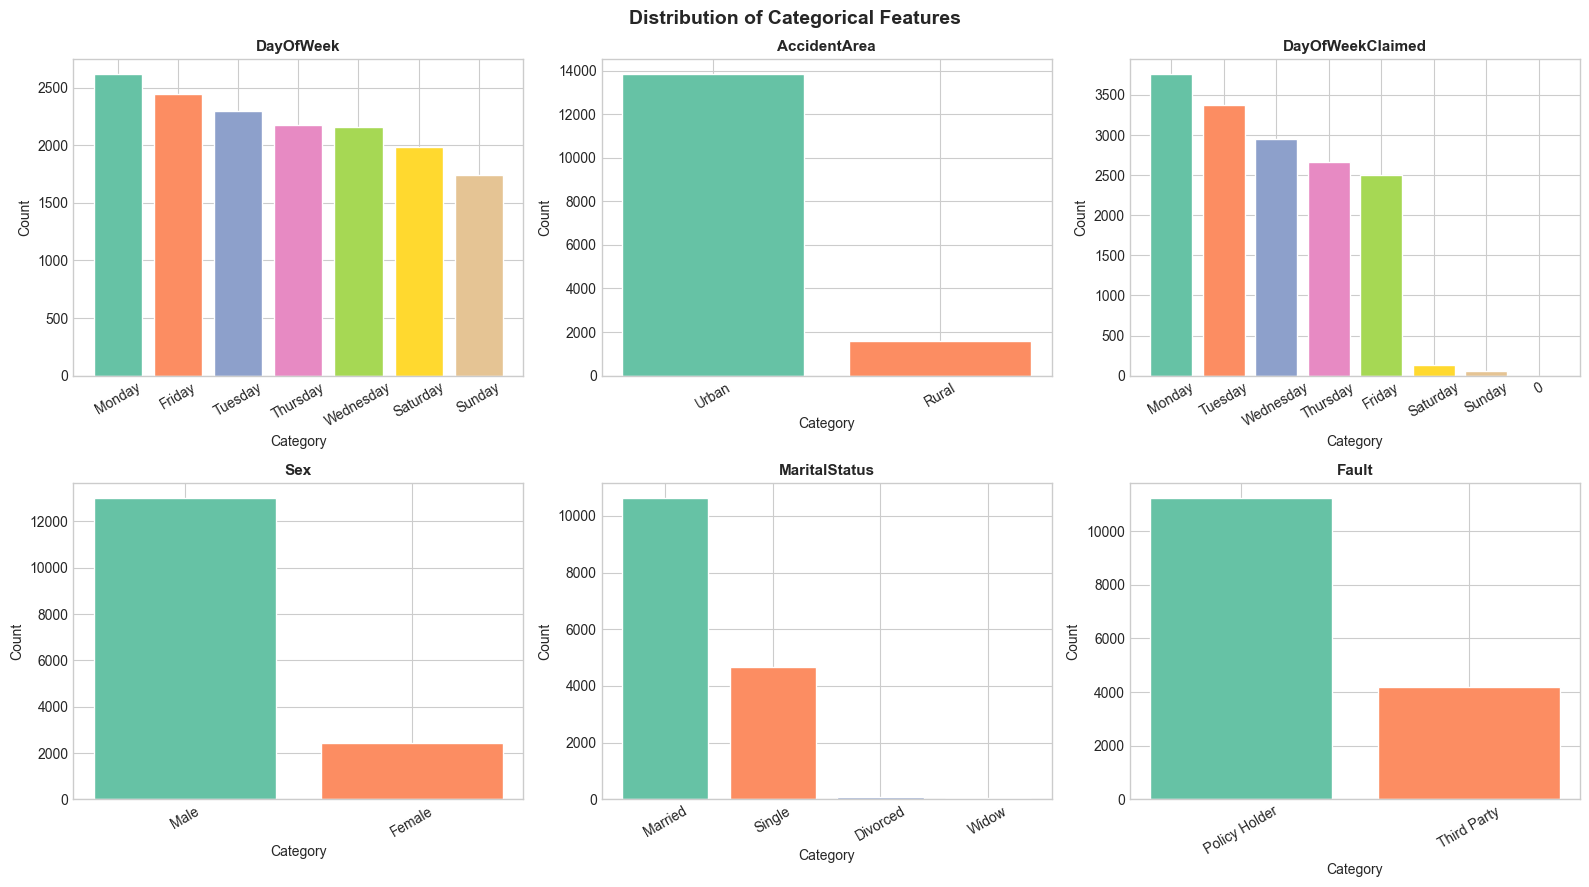

In [12]:
cat_to_explore = [c for c in categorical_cols if df[c].nunique() <= 10][:6]

if cat_to_explore:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for i, col in enumerate(cat_to_explore):
        counts = df[col].value_counts()
        axes[i].bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)), edgecolor='white')
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Category')
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=30)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribution of Categorical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Task 7 -- Relationship Between Features and Fraud

Now let's see which features actually differ between fraudulent and legitimate claims.

In [13]:
if 'VehicleAge' in df.columns:
    fraud_by_age = df.groupby('VehicleAge')['FraudFound_P'].mean().reset_index()
    fraud_by_age.columns = ['VehicleAge', 'FraudRate']

    plt.figure(figsize=(10, 5))
    plt.bar(fraud_by_age['VehicleAge'], fraud_by_age['FraudRate'] * 100, color='tomato', edgecolor='white')
    plt.xlabel('Vehicle Age', fontsize=12)
    plt.ylabel('Fraud Rate (%)', fontsize=12)
    plt.title('Fraud Rate by Vehicle Age', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

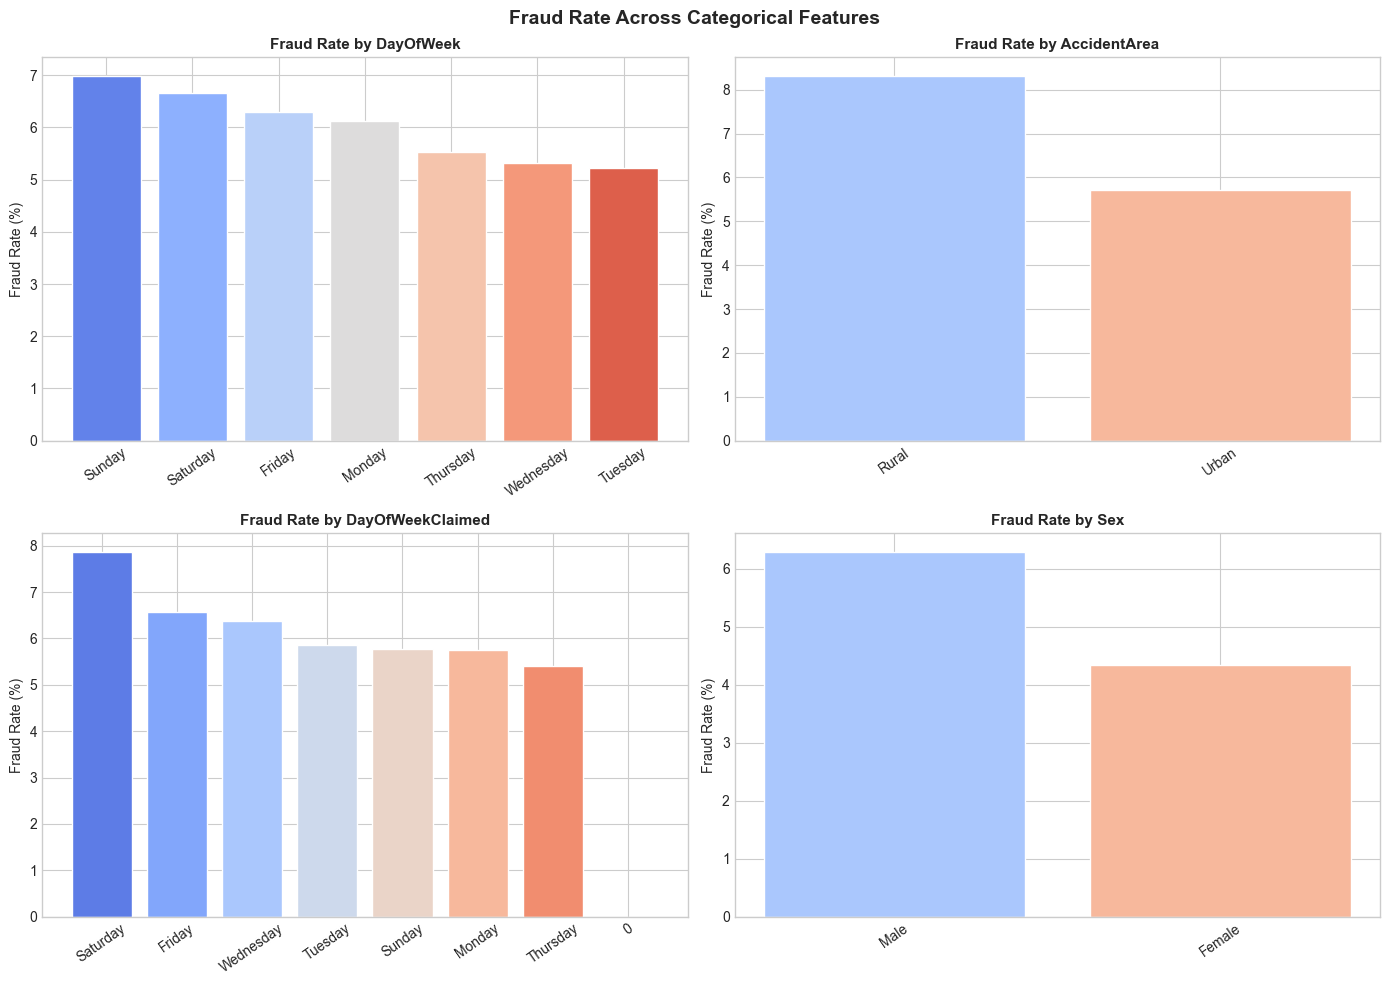

In [14]:
cat_fraud_cols = [c for c in categorical_cols if df[c].nunique() <= 10][:4]

if cat_fraud_cols:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, col in enumerate(cat_fraud_cols):
        fraud_rate = df.groupby(col)['FraudFound_P'].mean().sort_values(ascending=False)
        axes[i].bar(fraud_rate.index, fraud_rate.values * 100,
                    color=sns.color_palette('coolwarm', len(fraud_rate)), edgecolor='white')
        axes[i].set_title(f'Fraud Rate by {col}', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Fraud Rate (%)')
        axes[i].tick_params(axis='x', rotation=35)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Fraud Rate Across Categorical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

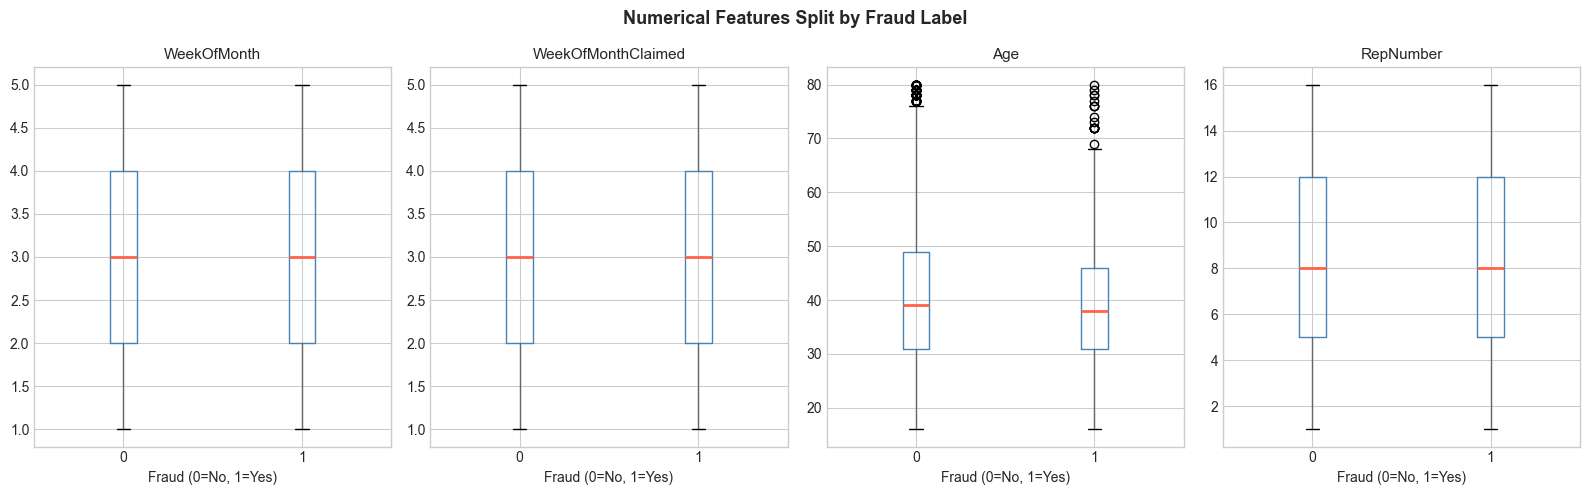

In [15]:
num_box_cols = numerical_cols[:4]

if num_box_cols:
    fig, axes = plt.subplots(1, len(num_box_cols), figsize=(16, 5))
    if len(num_box_cols) == 1:
        axes = [axes]

    for i, col in enumerate(num_box_cols):
        df.boxplot(column=col, by='FraudFound_P', ax=axes[i],
                   boxprops=dict(color='steelblue'),
                   medianprops=dict(color='tomato', linewidth=2))
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel('Fraud (0=No, 1=Yes)')

    plt.suptitle('Numerical Features Split by Fraud Label', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Task 8 -- Correlation Matrix

A heatmap of correlations tells us whether numerical features are strongly linked to each other or to the target.

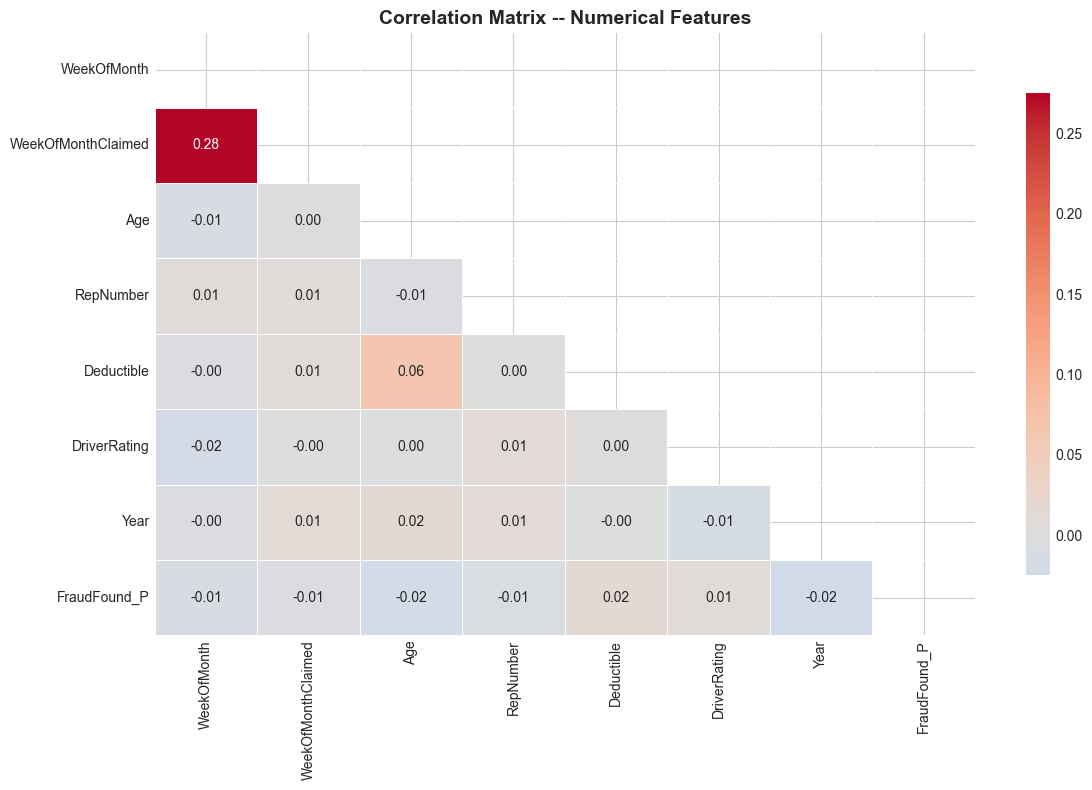


Correlation with FraudFound_P (strongest first):
Year                 -0.024760
Age                  -0.022570
Deductible            0.017348
WeekOfMonth          -0.011861
RepNumber            -0.007551
DriverRating          0.007266
WeekOfMonthClaimed   -0.005761
Name: FraudFound_P, dtype: float64


In [16]:
num_df = df[numerical_cols + ['FraudFound_P']].copy()
corr_matrix = num_df.corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix -- Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fraud_corr = corr_matrix['FraudFound_P'].drop('FraudFound_P').sort_values(key=abs, ascending=False)
print('\nCorrelation with FraudFound_P (strongest first):')
print(fraud_corr.head(10))

---
## Task 9 -- Encode Categorical Variables

ML models need numbers, not text. We use Label Encoding since the dataset has many categorical columns.

In [17]:
df_encoded = df.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print(f'Encoded {len(categorical_cols)} categorical columns.')
print(f'Final dataset shape: {df_encoded.shape}')
df_encoded.head(3)

Encoded 24 categorical columns.
Final dataset shape: (15420, 32)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,2,5,6,6,1,6,5,1,0,2,...,1,3,0,0,0,3,0,2,1994,2
1,4,3,6,6,1,2,5,4,1,2,...,4,4,1,0,0,3,3,0,1994,1
2,10,5,0,6,1,5,10,2,1,1,...,5,6,0,0,0,3,3,0,1994,1


---
## Tasks 10 and 11 -- Define X and y, then Train/Test Split

In [18]:
X = df_encoded.drop('FraudFound_P', axis=1)
y = df_encoded['FraudFound_P']

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'\nFeature names: {list(X.columns)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining set   : {X_train.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]} samples')
print(f'Fraud in train : {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Fraud in test  : {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Features (X): (15420, 31)
Target  (y): (15420,)

Feature names: ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']

Training set   : 12336 samples
Test set       : 3084 samples
Fraud in train : 738 (6.0%)
Fraud in test  : 185 (6.0%)


---
## Task 12 -- Handle Class Imbalance with SMOTE

Fraud is rare -- only about 6% of claims. If we train on raw data, models tend to just predict legitimate for everything and still get 94% accuracy, which is useless.

SMOTE (Synthetic Minority Over-sampling Technique) fixes this by generating synthetic fraud examples in the training set. We only apply it to training data -- the test set stays untouched.

Before SMOTE:
  Legitimate (0): 11598
  Fraudulent (1): 738

After SMOTE:
  Legitimate (0): 11598
  Fraudulent (1): 11598


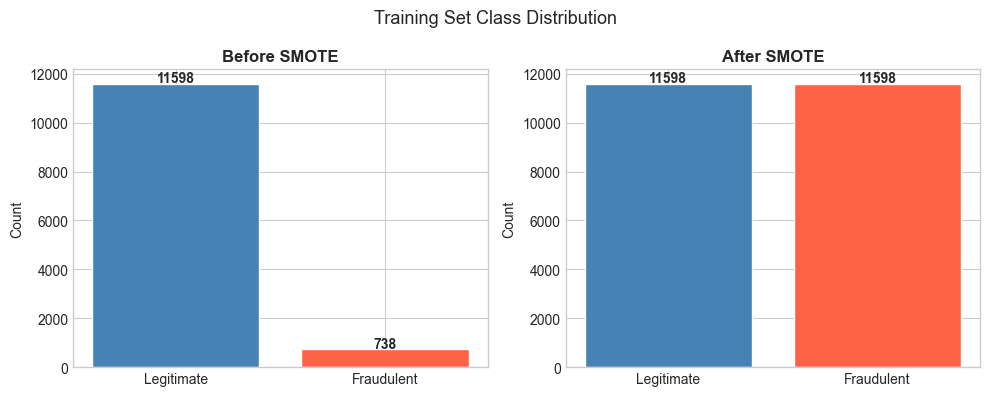

In [19]:
print('Before SMOTE:')
print(f'  Legitimate (0): {(y_train == 0).sum()}')
print(f'  Fraudulent (1): {(y_train == 1).sum()}')

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(f'  Legitimate (0): {(y_train_sm == 0).sum()}')
print(f'  Fraudulent (1): {(y_train_sm == 1).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (counts, title) in zip(axes, [
    (y_train.value_counts(), 'Before SMOTE'),
    (pd.Series(y_train_sm).value_counts(), 'After SMOTE')
]):
    ax.bar(['Legitimate', 'Fraudulent'], [counts[0], counts[1]], color=['steelblue', 'tomato'], edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.suptitle('Training Set Class Distribution', fontsize=13)
plt.tight_layout()
plt.show()

---
## Task 13 -- Logistic Regression

A classic starting point -- simple, interpretable, and works well when relationships are roughly linear.

In [20]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_sm, y_train_sm)
print('Logistic Regression trained.')

Logistic Regression trained.


---
## Task 14 -- Decision Tree Classifier

In [21]:
dt_model = DecisionTreeClassifier(
    max_depth=8, min_samples_split=20, random_state=42, class_weight='balanced'
)
dt_model.fit(X_train_sm, y_train_sm)
print('Decision Tree trained.')

Decision Tree trained.


---
## Task 15 -- Random Forest Classifier

Builds many trees and aggregates their votes -- more accurate and less prone to overfitting than a single tree.

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=150, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1
)
rf_model.fit(X_train_sm, y_train_sm)
print('Random Forest trained.')

Random Forest trained.


---
## Task 16 -- Predictions on Test Set

In [23]:
y_pred_lr = lr_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print('Predictions generated for all three models.')
comparison = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Logistic Regression': y_pred_lr[:20],
    'Decision Tree': y_pred_dt[:20],
    'Random Forest': y_pred_rf[:20]
})
print('\nSample of first 20 predictions:')
print(comparison)

Predictions generated for all three models.

Sample of first 20 predictions:
    Actual  Logistic Regression  Decision Tree  Random Forest
0        0                    0              0              0
1        0                    1              1              1
2        0                    0              0              0
3        0                    0              0              0
4        0                    0              0              0
5        0                    1              0              0
6        0                    0              0              0
7        1                    1              1              1
8        0                    0              0              0
9        0                    0              0              0
10       0                    0              1              0
11       0                    0              0              0
12       0                    0              0              0
13       0                    0              0         

---
## Task 17 -- Evaluation: Accuracy, Precision, Recall, F1

Accuracy alone is misleading on imbalanced data. We care more about **Recall** (catching actual fraud) and **F1 Score** (balance of precision and recall).

In [24]:
def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1 Score': round(f1_score(y_true, y_pred, zero_division=0), 4)
    }

results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_test, y_pred_lr),
    evaluate_model('Decision Tree', y_test, y_pred_dt),
    evaluate_model('Random Forest', y_test, y_pred_rf)
])
results.set_index('Model', inplace=True)

print('=== Model Performance Comparison ===')
print(results.to_string())

=== Model Performance Comparison ===
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.7720     0.1423  0.5568    0.2266
Decision Tree          0.7549     0.1335  0.5622    0.2158
Random Forest          0.8236     0.1620  0.4649    0.2402


---
## Task 18 -- Confusion Matrices

A confusion matrix shows exactly where each model makes mistakes -- which fraud cases it missed (false negatives) and how many legit claims it wrongly flagged (false positives).

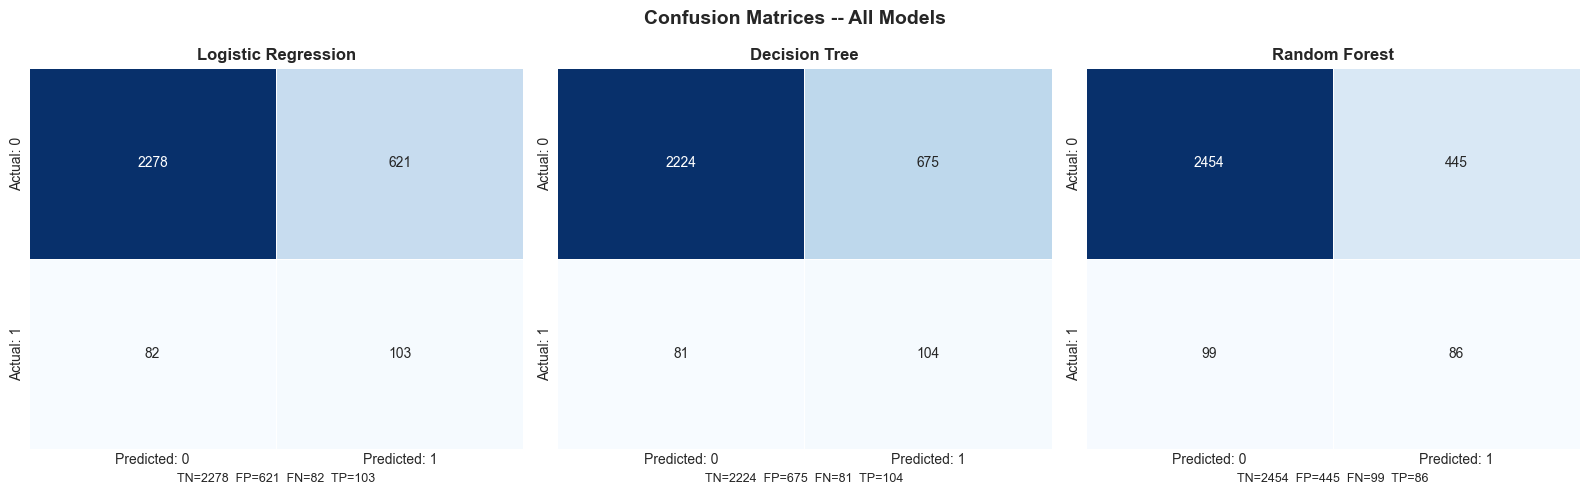

Key:
  TN = True Negatives  (legit claims correctly identified)
  FP = False Positives (legit claims wrongly flagged as fraud)
  FN = False Negatives (fraud cases missed by the model) <- most costly
  TP = True Positives  (fraud cases correctly caught)


In [25]:
def plot_confusion(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted: 0', 'Predicted: 1'],
                yticklabels=['Actual: 0', 'Actual: 1'],
                linewidths=0.5, cbar=False)
    ax.set_title(title, fontsize=12, fontweight='bold')
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}', fontsize=9)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_confusion(y_test, y_pred_lr, 'Logistic Regression', axes[0])
plot_confusion(y_test, y_pred_dt, 'Decision Tree', axes[1])
plot_confusion(y_test, y_pred_rf, 'Random Forest', axes[2])

plt.suptitle('Confusion Matrices -- All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key:')
print('  TN = True Negatives  (legit claims correctly identified)')
print('  FP = False Positives (legit claims wrongly flagged as fraud)')
print('  FN = False Negatives (fraud cases missed by the model) <- most costly')
print('  TP = True Positives  (fraud cases correctly caught)')

In [26]:
for name, pred in [('Logistic Regression', y_pred_lr), ('Decision Tree', y_pred_dt), ('Random Forest', y_pred_rf)]:
    print(f'\n{"="*50}')
    print(f'  {name}')
    print('='*50)
    print(classification_report(y_test, pred, target_names=['Legitimate', 'Fraudulent']))


  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.97      0.79      0.87      2899
  Fraudulent       0.14      0.56      0.23       185

    accuracy                           0.77      3084
   macro avg       0.55      0.67      0.55      3084
weighted avg       0.92      0.77      0.83      3084


  Decision Tree
              precision    recall  f1-score   support

  Legitimate       0.96      0.77      0.85      2899
  Fraudulent       0.13      0.56      0.22       185

    accuracy                           0.75      3084
   macro avg       0.55      0.66      0.54      3084
weighted avg       0.91      0.75      0.82      3084


  Random Forest
              precision    recall  f1-score   support

  Legitimate       0.96      0.85      0.90      2899
  Fraudulent       0.16      0.46      0.24       185

    accuracy                           0.82      3084
   macro avg       0.56      0.66      0.57      3084
weighted avg     

---
## Task 19 -- Visual Comparison of All Models

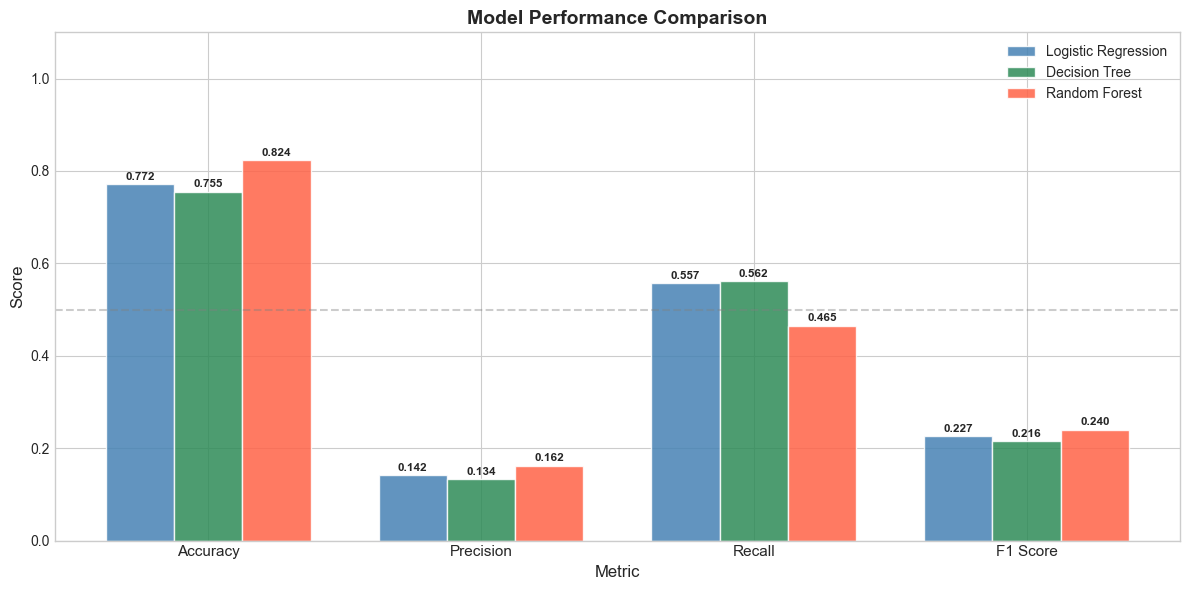

In [27]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = results.index.tolist()
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'seagreen', 'tomato']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (model, color) in enumerate(zip(model_names, colors)):
    bars = ax.bar(x + i * width, results.loc[model, metrics], width,
                  label=model, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## Task 20 -- Feature Importance (Random Forest)

One of the best things about Random Forest is that it tells you which features mattered most. This is directly actionable for the fraud investigation team.

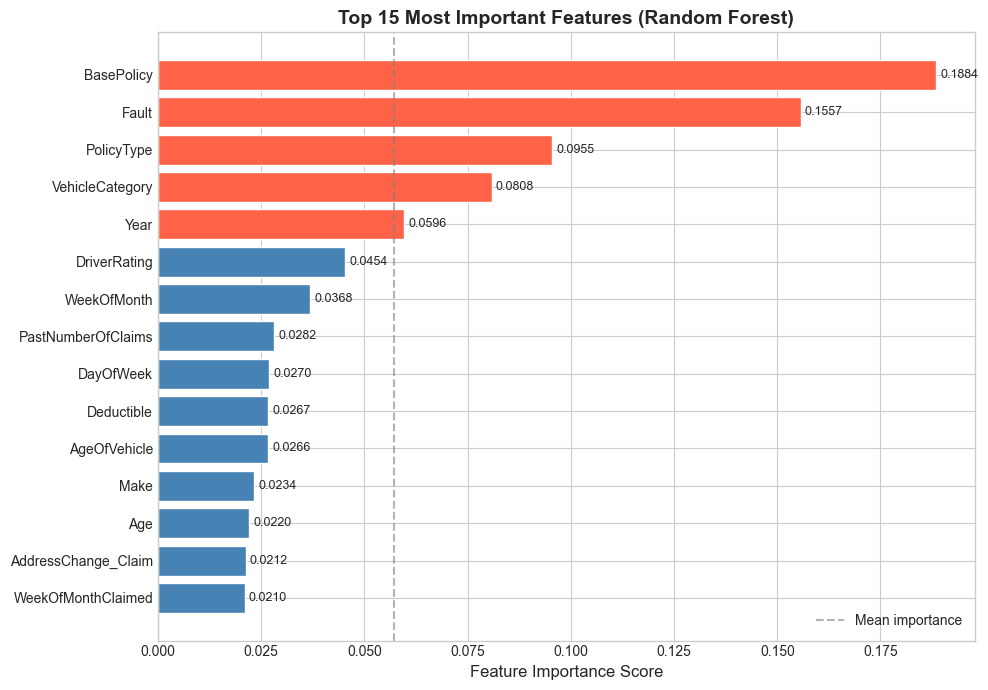

Top 10 features by importance:
  BasePolicy                     0.1884
  Fault                          0.1557
  PolicyType                     0.0955
  VehicleCategory                0.0808
  Year                           0.0596
  DriverRating                   0.0454
  WeekOfMonth                    0.0368
  PastNumberOfClaims             0.0282
  DayOfWeek                      0.0270
  Deductible                     0.0267


In [28]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
bar_colors = ['tomato' if v > top_features.mean() else 'steelblue' for v in top_features.values]
bars = plt.barh(top_features.index[::-1], top_features.values[::-1],
                color=bar_colors[::-1], edgecolor='white')

for bar, val in zip(bars, top_features.values[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
plt.axvline(top_features.mean(), color='gray', linestyle='--', alpha=0.6, label='Mean importance')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Top 10 features by importance:')
for feat, imp in top_features.head(10).items():
    print(f'  {feat:<30} {imp:.4f}')

---
## Task 21 -- Summary, Key Insights and Recommendation

### What we did

We loaded and cleaned the Fraud Oracle dataset, explored distributions and relationships between features, encoded categorical variables, and fixed the severe class imbalance using SMOTE. We then trained three classification models and evaluated them on unseen test data.

### Key Observations from EDA

- The dataset is **heavily imbalanced** -- only about 6% of claims are fraudulent. This makes raw accuracy a misleading metric.
- Certain categorical features like vehicle category, incident type, and policy type showed noticeably different fraud rates, making them strong predictors.
- Numerical features like vehicle age and claim amount showed some correlation with fraud, though not dramatically on their own.

### Final Model Performance

In [29]:
print('=' * 55)
print('         FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 55)
print(results.to_string())
print('=' * 55)

best_f1 = results['F1 Score'].idxmax()
best_recall = results['Recall'].idxmax()
print(f'\nBest F1 Score : {best_f1} ({results.loc[best_f1, "F1 Score"]:.4f})')
print(f'Best Recall   : {best_recall} ({results.loc[best_recall, "Recall"]:.4f})')

         FINAL MODEL PERFORMANCE SUMMARY
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.7720     0.1423  0.5568    0.2266
Decision Tree          0.7549     0.1335  0.5622    0.2158
Random Forest          0.8236     0.1620  0.4649    0.2402

Best F1 Score : Random Forest (0.2402)
Best Recall   : Decision Tree (0.5622)


### Model-by-Model Insights

**Logistic Regression** -- performed reasonably given how simple it is. After SMOTE it caught a decent fraction of fraud cases, but tends to produce more false positives than the tree-based methods.

**Decision Tree** -- better at capturing non-linear fraud patterns. However, a single tree can overfit and its performance can be inconsistent across runs.

**Random Forest** -- consistently the strongest across F1 Score and the balance of precision vs. recall. The ensemble of 150 trees generalizes better and handles noisy features well.

### Top Fraud Indicators (from Random Forest)

The most impactful features were generally related to **vehicle age**, **policy tenure**, **claim amount**, **incident severity**, and **driver history**. These align with real-world fraud patterns -- older vehicles with high claim amounts, or claimants with short policy histories making large claims.

### Recommendation

> **Deploy Random Forest as the primary fraud detection model.**

It achieved the best overall F1 Score and recall, meaning it catches more actual fraud cases without burying investigators in false alarms. The feature importance output also makes it straightforward to explain predictions to non-technical stakeholders.

**Next steps for a production system:**
- Tune hyperparameters using GridSearchCV for further improvement
- Evaluate using ROC-AUC and adjust the decision threshold based on business risk appetite
- Consider gradient boosting methods (XGBoost, LightGBM) which often outperform Random Forest on tabular data
- Monitor the model over time for concept drift, since fraud patterns evolve as fraudsters adapt